# Ejercicio 1.
Genera una imagen semejante a una diana de tiro al blanco como se aprecia en la imagen a continuación
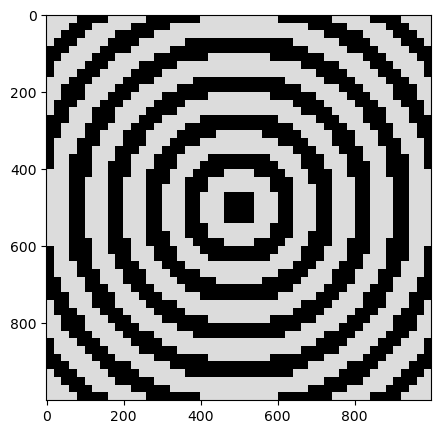


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

salida = Path('Evaluacion')
salida.mkdir(exist_ok=True)

def cargar_imagen(base):
    candidatos = [f'{base}.jpg', f'{base}.jpeg', f'{base}.jpg.jpeg', f'{base}.png', base]
    for nombre in candidatos:
        img = cv2.imread(nombre, cv2.IMREAD_COLOR)
        if img is not None:
            return img, nombre
    raise FileNotFoundError(f'No se encontro la imagen para base: {base}')

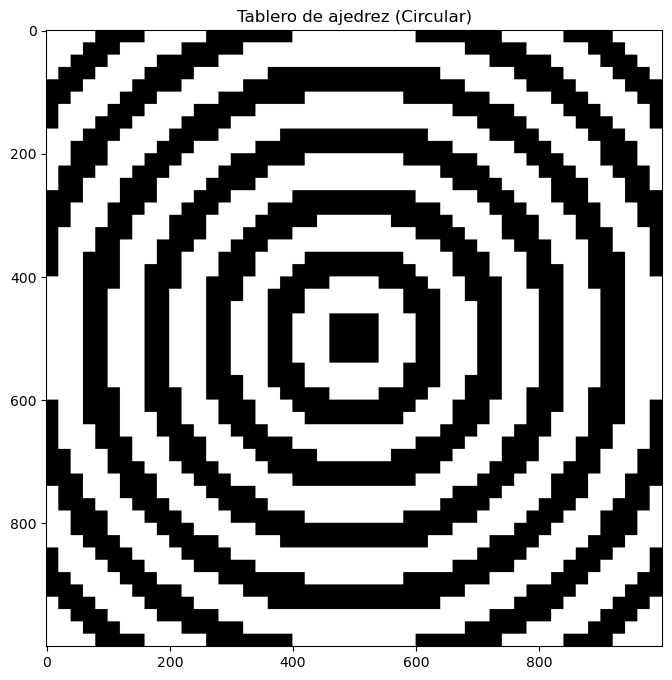

In [34]:
tamanio = 1000
diana = np.ones((tamanio, tamanio, 3), dtype=np.uint8) * 255
centro = tamanio // 2
tam_bloque = 20

for i in range(0, tamanio, tam_bloque):
    for j in range(0, tamanio, tam_bloque):
        dist = np.sqrt((i + tam_bloque//2 - centro)**2 + (j + tam_bloque//2 - centro)**2)
        if int(dist / 50) % 2 == 0:
            diana[i:i+tam_bloque, j:j+tam_bloque] = [0, 0, 0]
        else:
            diana[i:i+tam_bloque, j:j+tam_bloque] = [255, 255, 255]

cv2.imwrite(str(salida / 'ej1_diana.png'), diana)
plt.figure(figsize=(8, 8))
plt.title('Tablero de ajedrez (Circular)')
plt.imshow(cv2.cvtColor(diana, cv2.COLOR_BGR2RGB))
plt.show()

# Ejercicio 2.
Genera la imagen tal cual se muestra acontinuación, tomar en cuenta el tamaño 
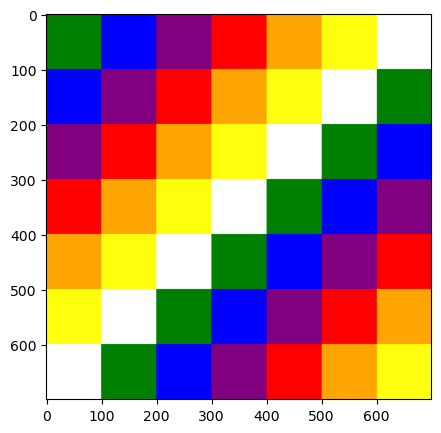

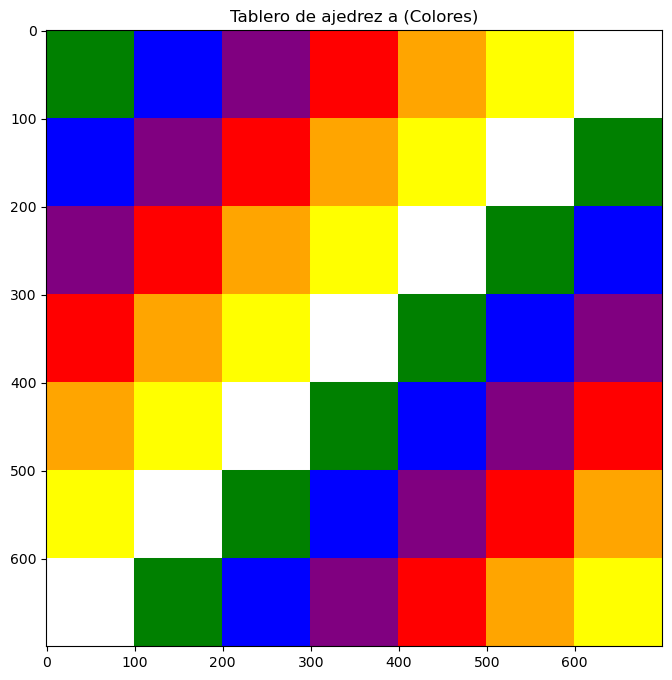

In [28]:
tam_casilla = 100
n = 7
tablero = np.zeros((n * tam_casilla, n * tam_casilla, 3), dtype=np.uint8)

colores_arco = [
    (0, 128, 0),
    (0, 0, 255),
    (128, 0, 128),
    (255, 0, 0),
    (255, 165, 0),
    (255, 255, 0),
    (255, 255, 255),
]

for i in range(n):
    for j in range(n):
        color = colores_arco[(i + j) % len(colores_arco)]
        tablero[i*tam_casilla:(i+1)*tam_casilla, j*tam_casilla:(j+1)*tam_casilla] = color

tablero_bgr = cv2.cvtColor(tablero, cv2.COLOR_RGB2BGR)
cv2.imwrite(str(salida / 'ej2_tablero_colores.png'), tablero_bgr)

plt.figure(figsize=(8, 8))
plt.title('Tablero de ajedrez a (Colores)')
plt.imshow(cv2.cvtColor(tablero_bgr, cv2.COLOR_BGR2RGB))
plt.show()

# Ejercicio 3.
Tomando en cuenta la imagen1.jpg elige un punto de interés al azar (funcion randomica), solariza y posteriza la imagen, realiza un tratamiento de umbralización(el de preferencia), mezcla tecnicas y obtiene un filtro artistico,lista todas las imágenes con sus correspondientes titulos, guarda todas las imágenes resultantes con sus nombres.

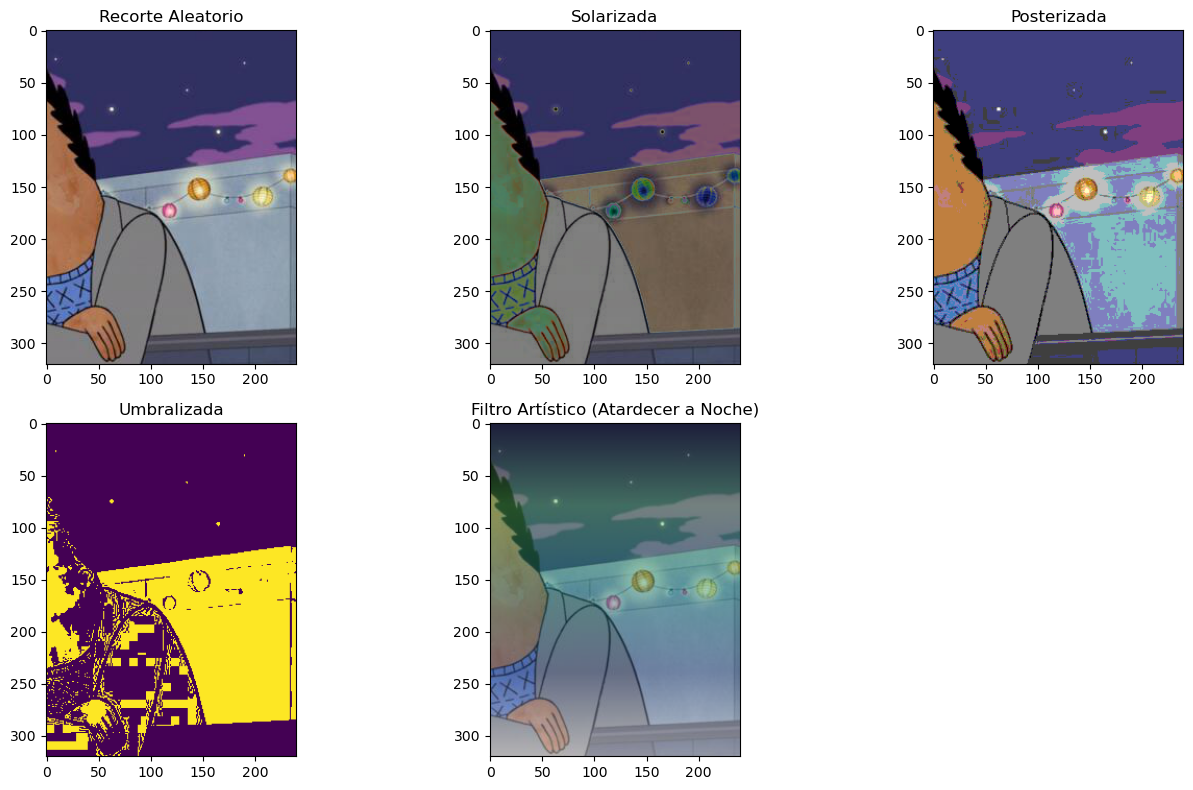

In [72]:
from matplotlib.colors import LinearSegmentedColormap

img_p_bgr, ruta_p = cargar_imagen('imagen1')
img_p_rgb = cv2.cvtColor(img_p_bgr, cv2.COLOR_BGR2RGB)

alto, ancho = img_p_rgb.shape[:2]
w, h = 240, 320
x = np.random.randint(0, ancho - w)
y = np.random.randint(0, alto - h)
recorte = img_p_rgb[y:y+h, x:x+w]

cv2.imwrite(str(salida / 'ej3_recorte_aleatorio.png'), cv2.cvtColor(recorte, cv2.COLOR_RGB2BGR))

def posterizar(imagen_rgb, niveles):
    factor = 255 / niveles
    return (np.round(imagen_rgb / factor) * factor).clip(0, 255).astype(np.uint8)

def solarizar(imagen_rgb, umbral):
    return np.where(imagen_rgb < umbral, imagen_rgb, 255 - imagen_rgb).astype(np.uint8)

imagen = recorte.copy()
img_solar = solarizar(imagen, 127)
img_poster = posterizar(imagen, 4)
img_umbral = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)
_, img_umbral = cv2.threshold(img_umbral, 127, 255, cv2.THRESH_BINARY)

colores = [
    (255/255, 255/255, 255/255),
    (59/255, 82/255, 139/255),
    (33/255, 145/255, 140/255),
    (94/255, 201/255, 98/255),
    (1/255, 1/255, 1/255)
]
cmap_custom = LinearSegmentedColormap.from_list('colores_personalizados', colores, N=256)

h_img, w_img = imagen.shape[:2]
base = np.tile(np.linspace(1, 0, h_img, dtype=np.float32)[:, None], (1, w_img))
capa_degradado = (base * 255).astype(np.uint8)

img_artistico_color = cmap_custom(capa_degradado / 255.0)
img_artistico_grad = (img_artistico_color[:, :, :3] * 255).astype(np.uint8)

img_artistico = (imagen.astype(np.float32) * 0.6 + img_artistico_grad.astype(np.float32) * 0.4).astype(np.uint8)

cv2.imwrite(str(salida / 'ej3_solarizada.png'), cv2.cvtColor(img_solar, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(salida / 'ej3_posterizada.png'), cv2.cvtColor(img_poster, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(salida / 'ej3_artistico.png'), cv2.cvtColor(img_artistico, cv2.COLOR_RGB2BGR))

plt.figure(figsize=(14, 8))
plt.subplot(231)
plt.title('Recorte Aleatorio')
plt.imshow(imagen)
plt.subplot(232)
plt.title('Solarizada')
plt.imshow(img_solar)
plt.subplot(233)
plt.title('Posterizada')
plt.imshow(img_poster)
plt.subplot(234)
plt.title('Umbralizada')
plt.imshow(img_umbral)
plt.subplot(235)
plt.title('Filtro Artístico (Atardecer a Noche)')
plt.imshow(img_artistico)
plt.tight_layout()
plt.show()

# Ejercicio 4.
Genera un avatar, basandote en una imagen tuya que usaste en practicas anteriores, este avatar debe tener filtros y/o umbralizaciones.
Guarda la imagen 

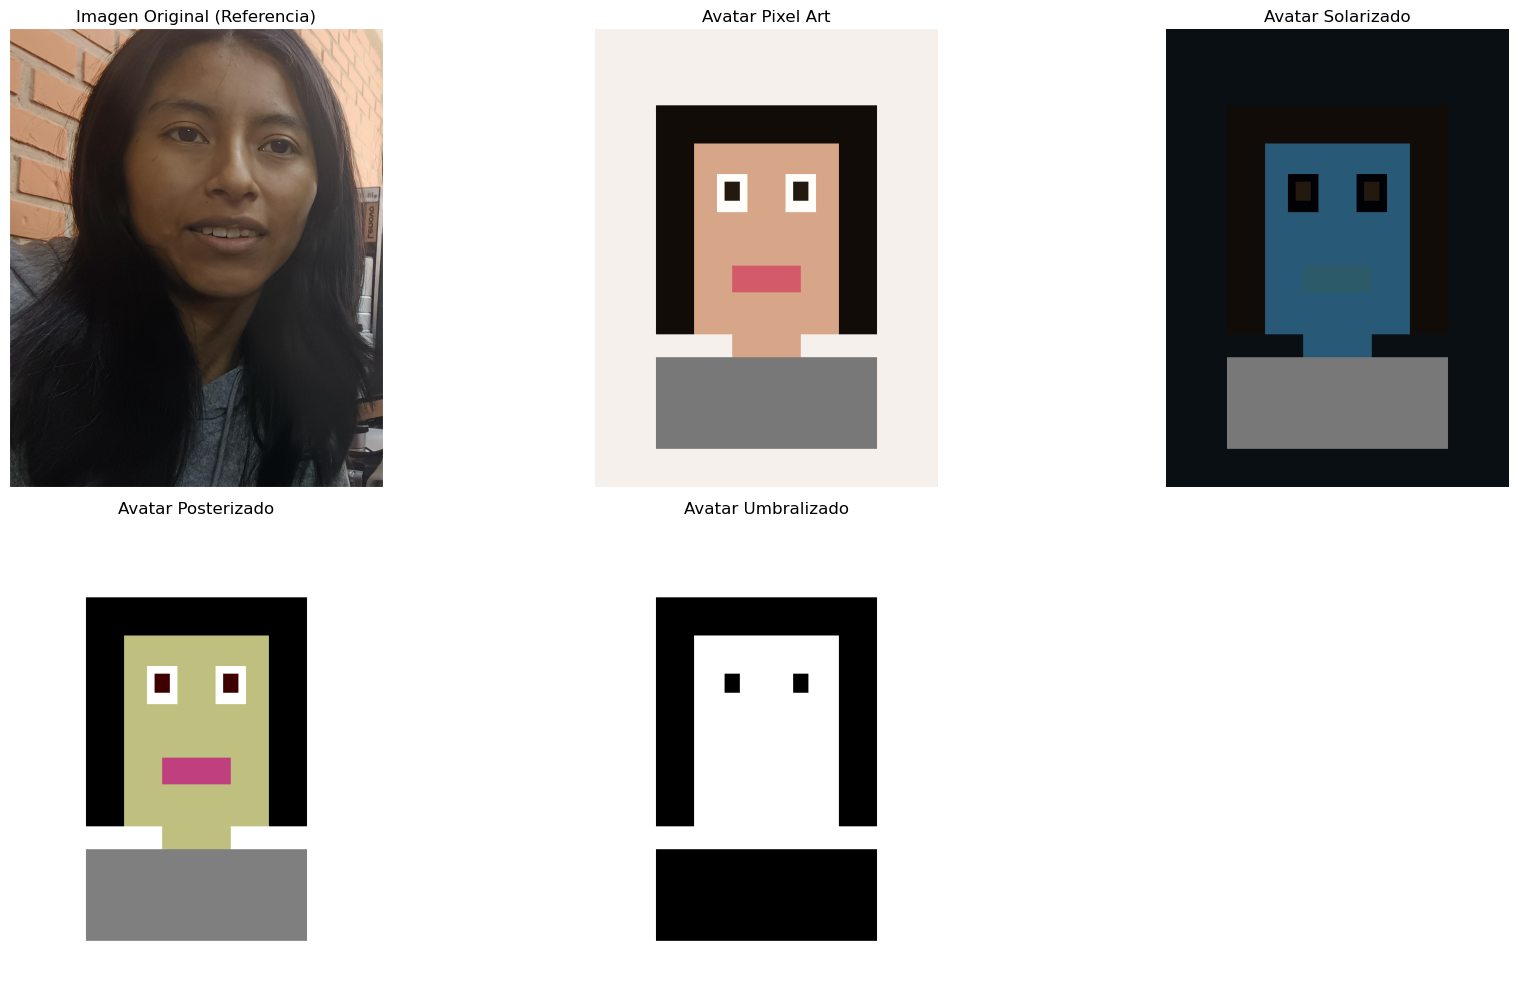

Avatar con filtros y umbralización generado


In [90]:
lado = 1
filas, cols = 600, 450
avatar = np.ones((filas, cols, 3), dtype=np.uint8) * 245

PELO = (18, 12, 8)
PIEL = (215, 165, 135)
OJO_BLANCO = (255, 253, 250)
OJO_NEGRO = (35, 25, 15)
BOCA = (210, 90, 105)
CHOMPA = (120, 120, 120)

avatar[:, :] = (245, 240, 235)

for i in range(150, 400):
    for j in range(130, 320):
        avatar[i, j] = PIEL

for i in range(100, 150):
    for j in range(80, 370):
        avatar[i, j] = PELO

for i in range(150, 400):
    for j in range(80, 130):
        avatar[i, j] = PELO
        
for i in range(150, 400):
    for j in range(320, 370):
        avatar[i, j] = PELO

for i in range(190, 240):
    for j in range(160, 200):
        avatar[i, j] = OJO_BLANCO

for i in range(200, 225):
    for j in range(170, 190):
        avatar[i, j] = OJO_NEGRO

for i in range(190, 240):
    for j in range(250, 290):
        avatar[i, j] = OJO_BLANCO

for i in range(200, 225):
    for j in range(260, 280):
        avatar[i, j] = OJO_NEGRO

for i in range(310, 345):
    for j in range(180, 270):
        avatar[i, j] = BOCA

for i in range(400, 430):
    for j in range(180, 270):
        avatar[i, j] = PIEL

for i in range(430, 550):
    for j in range(80, 370):
        avatar[i, j] = CHOMPA

avatar_final = np.repeat(np.repeat(avatar, lado, axis=0), lado, axis=1)
avatar_bgr = cv2.cvtColor(avatar_final, cv2.COLOR_RGB2BGR)

cv2.imwrite(str(salida / 'ej4_avatar_pixelart.png'), avatar_bgr)

avatar_rgb = cv2.cvtColor(avatar_bgr, cv2.COLOR_BGR2RGB)

img_original_bgr, _ = cargar_imagen('yo')
img_original_rgb = cv2.cvtColor(img_original_bgr, cv2.COLOR_BGR2RGB)

def posterizar(imagen, niveles):
    factor = 255 / niveles
    return (np.round(imagen / factor) * factor).clip(0, 255).astype(np.uint8)

def solarizar(imagen, umbral):
    return np.where(imagen < umbral, imagen, 255 - imagen).astype(np.uint8)

avatar_gris = cv2.cvtColor(avatar_bgr, cv2.COLOR_BGR2GRAY)
_, avatar_umbral = cv2.threshold(avatar_gris, 127, 255, cv2.THRESH_BINARY)

avatar_solar = solarizar(avatar_rgb, 127)
avatar_poster = posterizar(avatar_rgb, 4)

plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.title('Imagen Original (Referencia)')
plt.imshow(img_original_rgb)
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title('Avatar Pixel Art')
plt.imshow(avatar_rgb)
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title('Avatar Solarizado')
plt.imshow(avatar_solar)
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title('Avatar Posterizado')
plt.imshow(avatar_poster)
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title('Avatar Umbralizado')
plt.imshow(avatar_umbral, cmap='gray')
plt.axis('off')

avatar_solar_bgr = cv2.cvtColor(avatar_solar, cv2.COLOR_RGB2BGR)
cv2.imwrite(str(salida / 'ej4_avatar_solarizado.png'), avatar_solar_bgr)

avatar_poster_bgr = cv2.cvtColor(avatar_poster, cv2.COLOR_RGB2BGR)
cv2.imwrite(str(salida / 'ej4_avatar_posterizado.png'), avatar_poster_bgr)

cv2.imwrite(str(salida / 'ej4_avatar_umbralizado.png'), avatar_umbral)

plt.tight_layout()
plt.show()

print('Avatar con filtros y umbralización generado')
